# Article 1 — Experiment 1: is EXPERT injecting out-of-expertise probability mass?

This notebook reads only the **valid holdout-derived** Experiment 1 results. It does not train a student.

## Main findings

1. The mechanism is empirically present. Selected EXPERT teachers place substantial mass outside their demonstrated expertise, most strongly on CIFAR-10. The final EXPERT target also puts non-trivial mass on classes supported by none of the selected teachers.
2. The signal is not universal. MNIST is nearly clean under IID and single-class specialization; FMNIST single-class is also effectively clean. Thus support restriction is motivated by difficult/regime-specific conditions rather than assumed to help everywhere.
3. More specialization changes both support size and the number of selected teachers, but the unwanted-mass trend is not strictly monotone across every dataset/regime. Interpret the mechanism jointly with target quality, not from heterogeneity labels alone.
4. Within conditions, larger individual out-of-expertise mass is generally associated with larger target NLL and lower true-class probability. This is diagnostic evidence only; it is not yet evidence that a support-restricted student improves.

**Definitions.** Individual mass is `sum_c p_teacher(c) · 1[c outside teacher support]`, averaged over selected teachers. Final-target union mass is the EXPERT target mass on classes supported by **none** of the teachers selected for that proxy example.

In [1]:
from pathlib import Path
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
repo = next((p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'OUTPUTS').exists()), None)
assert repo is not None, 'Open this notebook from the KD_v5 repository or a subdirectory.'
result_root = repo / 'OUTPUTS/experiments/article_1_server_expertise/experiment_1'
candidates = sorted(result_root.glob('diagnostic_*/results.csv'))
assert candidates, f'No valid Experiment 1 results beneath {result_root}'
results_path = candidates[-1]
results = pd.read_csv(results_path)
assert set(results.scientific_status) == {'valid_holdout_mask'}
order = ['iid', 'alpha1p0', 'alpha0p5', 'alpha0p1', 'multi', 'single']
datasets = ['cifar10', 'fmnist', 'mnist']
results['regime'] = pd.Categorical(results.regime, order, ordered=True)
print(f'{len(results)} valid conditions from {results_path.parent.name}: ' +
      f'{results.dataset.nunique()} datasets × {results.seed.nunique()} seeds × {results.regime.nunique()} regimes')

54 valid conditions from diagnostic_9debbe1013cd: 3 datasets × 3 seeds × 6 regimes


In [2]:
headline = (results.groupby('dataset', observed=True)
            [['mean_selected_teacher_out_of_expertise_mass',
              'mean_target_mass_outside_selected_union_support',
              'corr_individual_outside_vs_target_nll']]
            .mean()
            .rename(columns={
                'mean_selected_teacher_out_of_expertise_mass': 'teacher outside-expertise mass',
                'mean_target_mass_outside_selected_union_support': 'target mass outside selected union',
                'corr_individual_outside_vs_target_nll': 'within-condition corr(mass, NLL)'})
            .round(3))
headline

,teacher outside-expertise mass,target mass outside selected union,"within-condition corr(mass, NLL)"
dataset,,,
cifar10,0.394,0.273,0.673
fmnist,0.150,0.064,0.802
mnist,0.077,0.015,0.744


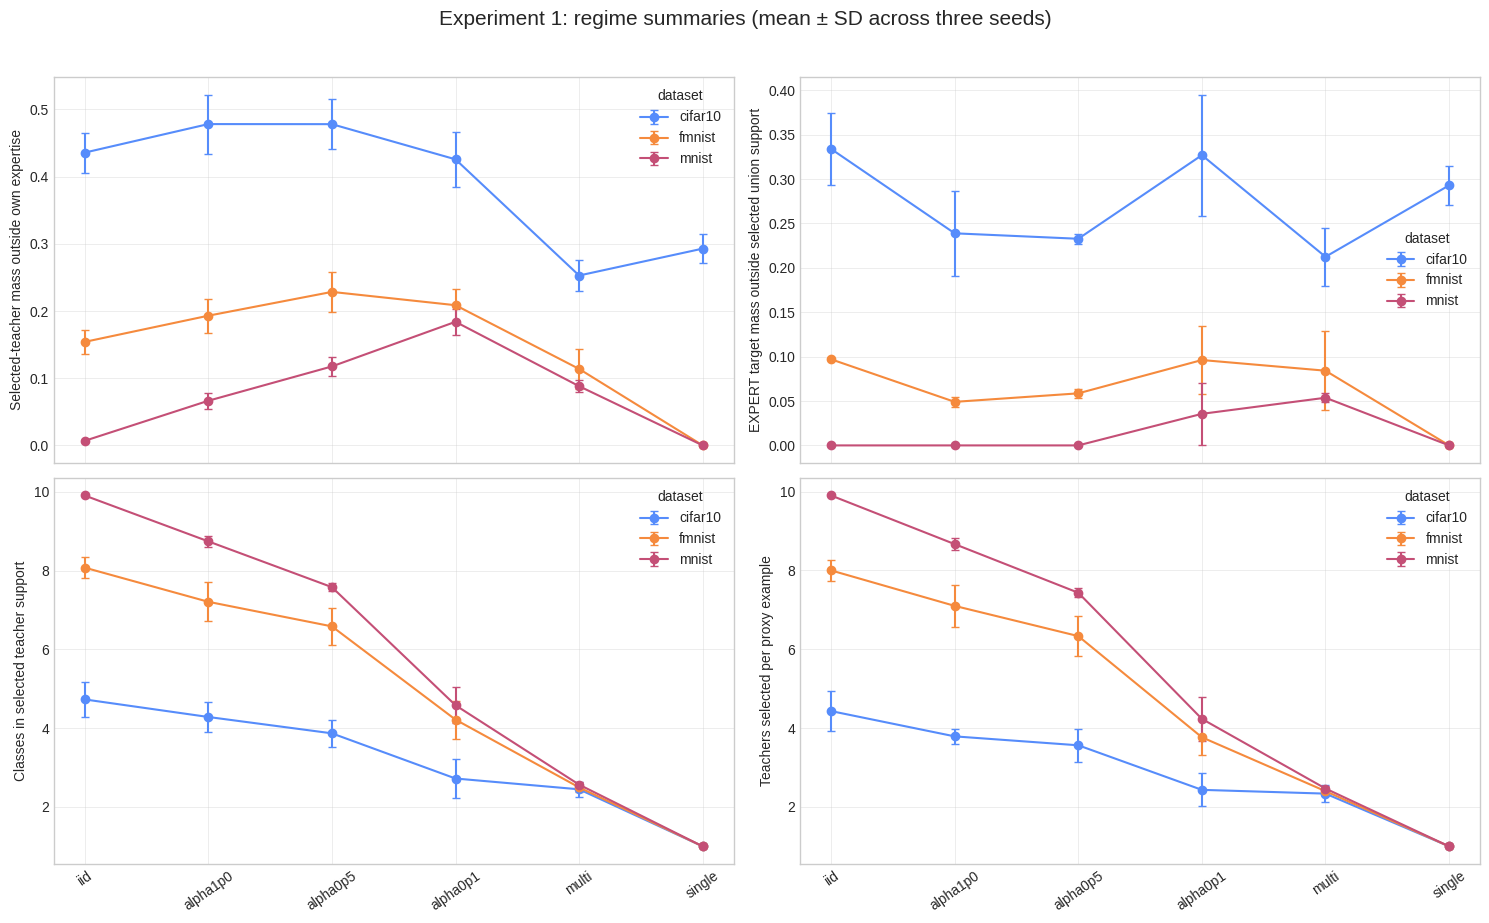

In [3]:
def mean_sd(metric, dataset):
    x = (results[results.dataset.eq(dataset)].groupby('regime', observed=True)[metric]
         .agg(['mean', 'std']).reindex(order))
    return x['mean'].to_numpy(), x['std'].fillna(0).to_numpy()

fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharex=True)
specs = [
    ('mean_selected_teacher_out_of_expertise_mass', 'Selected-teacher mass outside own expertise'),
    ('mean_target_mass_outside_selected_union_support', 'EXPERT target mass outside selected union support'),
    ('mean_selected_teacher_support_size', 'Classes in selected teacher support'),
    ('mean_selected_teachers', 'Teachers selected per proxy example'),
]
for ax, (metric, ylabel) in zip(axes.flat, specs):
    for dataset in datasets:
        mean, sd = mean_sd(metric, dataset)
        ax.errorbar(order, mean, yerr=sd, marker='o', capsize=3, label=dataset)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=35)
    ax.legend(title='dataset')
fig.suptitle('Experiment 1: regime summaries (mean ± SD across three seeds)', y=1.02, fontsize=15)
fig.tight_layout()

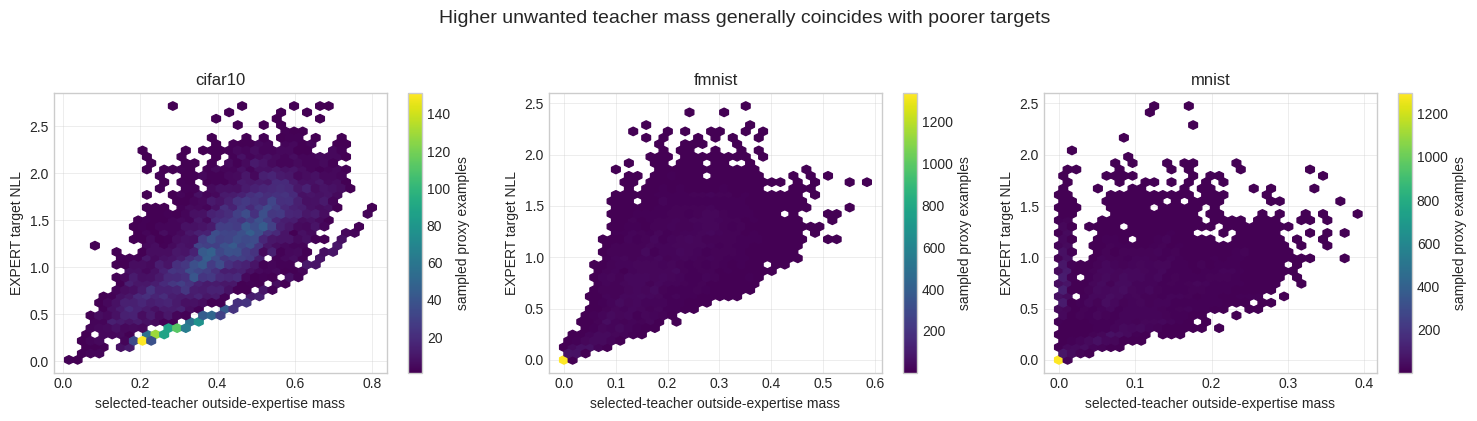

In [4]:
# Sample proxy observations evenly from every condition, then show the local
# relationship that the summary correlations quantify.
rng = np.random.default_rng(7)
sampled = []
for row in results.itertuples(index=False):
    with np.load(repo / row.observation_artifact) as obs:
        x = obs['selected_mean_teacher_out_of_expertise_mass']
        y = obs['target_nll']
        valid = np.isfinite(x) & np.isfinite(y)
        take = rng.choice(np.flatnonzero(valid), size=min(400, valid.sum()), replace=False)
        sampled.append(pd.DataFrame({'dataset': row.dataset, 'outside_mass': x[take], 'target_nll': y[take]}))
sampled = pd.concat(sampled, ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, dataset in zip(axes, datasets):
    data = sampled[sampled.dataset.eq(dataset)]
    hb = ax.hexbin(data.outside_mass, data.target_nll, gridsize=35, mincnt=1, cmap='viridis')
    ax.set(title=dataset, xlabel='selected-teacher outside-expertise mass', ylabel='EXPERT target NLL')
    fig.colorbar(hb, ax=ax, label='sampled proxy examples')
fig.suptitle('Higher unwanted teacher mass generally coincides with poorer targets', y=1.04, fontsize=14)
fig.tight_layout()

# Next scientific action: use these plots to preregister the support-restriction
# comparison; do not infer student improvement from this diagnostic alone.